In [1]:
import numpy as np
import cv2
import os
from keras.datasets import mnist
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import transforms
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset
import torch
import torch.optim as optim
from torch.autograd import Variable
from sklearn.model_selection import train_test_split

# Utils

In [2]:
def add_noise(imgs):
    """
    Main function add noise to images.

    Here we load the dataset, add gaussian, poisson, speckle
    'gauss'     Gaussian-distributed additive noise.
    'speckle'   Multiplicative noise using out = image + n*image,where
                n is uniform noise with specified mean & variance.
    """
    row, col = 28, 28
    noisy_output = np.zeros((len(imgs), row, col))
    
    # adding noise
    for idx, img in enumerate(imgs):
        img = img.astype(np.float32)
        noise_type = random.choice(["gaussian", "speckle"])

        if noise_type == "gaussian":
            mean, var = -10, 100
            sigma = var**.5
            noise = np.random.normal(20, 10, img.shape)
            img += noise

        elif noise_type == "speckle":
            noise = np.random.randn(row,col)
            noise = noise.reshape(row,col)
            img += img * noise


        noisy_output[idx] = img
        
    return noisy_output

# Load and Split Data

In [3]:
# Loading the dataset from Keras
(xtrain, ytrain), (xtest, ytest) = mnist.load_data()
xtrain, xval, ytrain, yval = train_test_split(xtrain, ytrain, test_size=10000, random_state=42)

11493376/11490434 [==============================] - 0s 0us/step


In [4]:
print(f"Number of Training Set datapoints: {len(xtrain)}")
print(f"Number of Validation Set datapoints: {len(xval)}")
print(f"Number of Test Set datapoints: {len(xtest)}")

Number of Training Set datapoints: 50000
Number of Validation Set datapoints: 10000
Number of Test Set datapoints: 10000


## Add Noise

In [5]:
"""
Split Data and Add Noise

We split the 50k training data into 2 sets where we add 1 type of noise to each set. 
"""
import random

# We define two types of noises
noise_types = ["gaussian","speckle"]

# adding noise to xtrain and xtest
noisy_xtrain = add_noise(xtrain)
noisy_xval = add_noise(xval)
noisy_xtest = add_noise(xtest)

## Visualize Noise

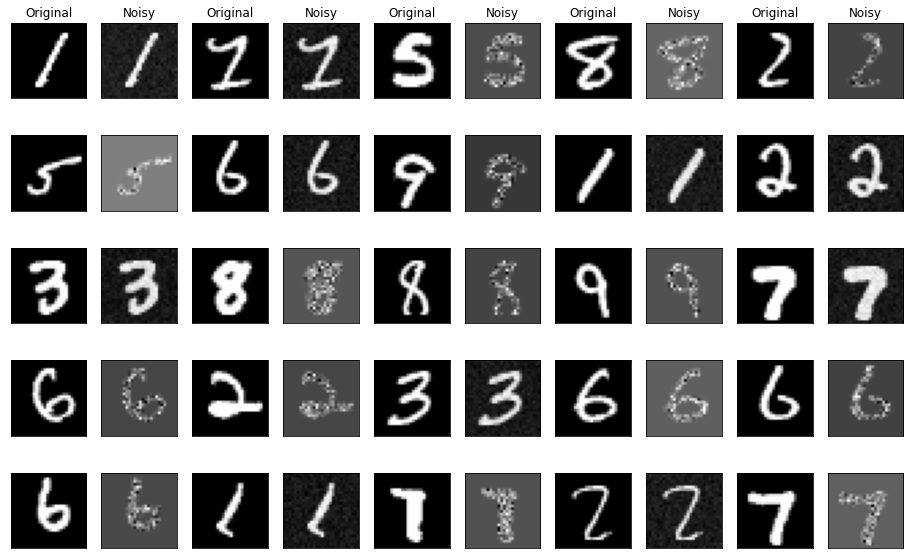

In [6]:
"""
Visualization of Original Image vs. Noisy Image.
"""
import itertools
f, axes = plt.subplots(5, 10, figsize=(16, 10))

for xid, yid in itertools.product(range(5), range(0, 10, 2)):
    image_id = random.randint(0, 50000)
    
    # display original image
    axes[xid, yid].imshow(xtrain[image_id],cmap="gray")
    axes[xid, yid].set(xticks = [], yticks = [])

    # display original image
    axes[xid, yid+1].imshow(noisy_xtrain[image_id],cmap="gray")
    axes[xid, yid+1].set(xticks = [], yticks = [])
    
    if xid == 0:
        axes[xid, yid].set(title = "Original")
        axes[xid, yid+1].set(title = "Noisy")

## Data Loader

In [7]:
"""
Dataset
"""
class noisedDataset(Dataset):
  
    def __init__(self, noisy_dataset, clean_dataset, labels, transform):
        self.noise = noisy_dataset
        self.clean = clean_dataset
        self.labels = labels
        self.transform = transform
  
    def __len__(self):
        return len(self.noise)
  
    def __getitem__(self,idx):
        noisy_x = self.noise[idx]
        clean_x = self.clean[idx]
        y = self.labels[idx]
    
        if self.transform != None:
            noisy_x = self.transform(noisy_x)
            clean_x = self.transform(clean_x)

        return (noisy_x, clean_x, y)  

In [8]:
tsfms = transforms.Compose([
    transforms.ToTensor()
])

trainset = noisedDataset(noisy_xtrain, xtrain, ytrain, tsfms)
valset = noisedDataset(noisy_xval, xval, yval, tsfms)
testset = noisedDataset(noisy_xtest, xtest, ytest, tsfms)

In [9]:
batch_size = 32

train_dataloader = DataLoader(trainset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(valset, batch_size=1, shuffle=True)
test_dataloader = DataLoader(testset, batch_size=1, shuffle=True)

#**Documentation**
**In this assignment, we are to train a model that will help with denoise the images from mnist which was added with noise randomly using gaussian distribution and speckle.**

**The dataset after adding noise will be returned as a tuple of noisy image, original clean image and image labels.**

**Our goal is to use an autoencoder to denoise the image.**

**An autoencoder consists of an input, an encoder, a bottleneck, a decoder and output.**

**The output will have the same dimension as the input. The decoder is often the mirror of the encoder.**

**We have an requirement in this assignment to have the bottleneck of 64 nodes, which is the to bottleneck will have be a 64*1 vector.**

**In my model, the autoencoder has three layers. The first layer takes the input and output a dimension of 512 vector. The second layer outputs the 512 size vector to size of 256. The third outputs the 256 size vector to size of 64, which is the bottleneck. The decoder than takes the input from bottleneck of size 64 and with three layers that mirrors the encoder, returns a final output that is size of 784, which is the flattened size of a 28-by-28 image from mnist.**



# Denoising Autoencoder (DAE) Model

In [10]:
"""
Autoencoder model
"""
# TODO: Main model definition + any utilities or custom layers
class DAE(nn.Module):
    # ---------- TODO: code here ------------ #
    def __init__(self):
        super(DAE,self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28,512),
            nn.ReLU(True),
            nn.Linear(512,256),
            nn.ReLU(True),
            nn.Linear(256,64),
            nn.ReLU(True),
      )
        self.decoder = nn.Sequential(
            nn.Linear(64,256),
            nn.ReLU(True),
            nn.Linear(256,512),
            nn.ReLU(True),
            nn.Linear(512,28*28),
            
      )
    def forward(self,x):
        #print(x.shape)
        encode = self.encoder(x)
        decode = self.decoder(encode)

        return decode


model = DAE()

# Training

#**Documentation**

**For the training of this model. Since its a semi-unsupervised model, the output of the model will not be comared with a label of the dataset, but instead with the original dataset. This will allow use to clean the noisy that we added from the original.**

**The optimizer I chose to use is SGD because it converged better than Adam in this scenerio.**

**The images all had to be flattened as the model we used is linear, which works only on vectors.** 

**Every epoch, validation is used to see how the convergence is.**

**This model learns useful features as it cleans the images with different kind of noise.** 

**The function tqdm is a iterator that helps to visualize training better.**


*  https://github.com/tqdm/tqdm










In [11]:
'''
returns the trained model after 100 epochs and the loss in validation at each epoch

After each training, the model is validated. 

The returned epoch_loss is the MSEloss of the output from the current model compared with the original no-noise dataset

'''

def train(train_dataloader, val_dataloader, device, config):
    if torch.cuda.is_available()==True:
      print("is training on gpu")
    else:
      print("something is wrong")
    model = DAE().to(device)
    # epochs_loss is losses for epochs --> len(epochs_loss) = number of epochs
    epochs_loss = []
    

    # ---------- TODO: code here ------------ #
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(),lr=config['lr'],weight_decay=config['weight_decay'],momentum=config['momentum'])

    for epoch in range(config['num_epochs']):
        model.train()
        for noisy,original,target in tqdm(train_dataloader,position=0):
      
        #flatten to use fully connected layers
            noisy = noisy.view(noisy.size(0),-1).type(torch.FloatTensor).to(device)
            original = original.view(original.size(0),-1).type(torch.FloatTensor).to(device)
        #target = target.view(target.size(0),-1).type(torch.FloatTensor)
            output = model(noisy)
            loss  = criterion(output,original)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print("epoch is",(epoch+1))
        print("loss is",loss.item())
      
        
        validation_loss = 0

        model.eval()
        with torch.no_grad():
            for (noisy,original,target) in val_dataloader:
                noisy = noisy.view(noisy.size(0),-1).type(torch.FloatTensor).to(device)
                original = original.view(original.size(0),-1).type(torch.FloatTensor).to(device)
                output = model(noisy)
                #compared with the original image
                validation_loss += criterion(output,original).item()
            #validation loss per eopch is deleted with the length of each dataset to average
            validation_loss /= len(val_dataloader.dataset)
            print("validation loss is:",validation_loss)
            epochs_loss.append(validation_loss)
    return model, epochs_loss 

# Run

In [12]:
def save_model_colab_for_submission(model):  # if you are running on colab
  drive.mount('/content/gdrive/', force_remount=True)
  torch.save(model.to(torch.device("cpu")), '/content/gdrive/My Drive/model.pt')

In [13]:
def run():
    # set parameters lr=1e-3,weight_decay=3e-3,momentum = 0.98
    config = {
        'num_epochs': 100,
        'lr': 1e-3,
        'weight_decay':3e-3,
        'momentum' : 0.98,
    }

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, epochs_loss = train(train_dataloader, val_dataloader, device, config)
    
    # save model in checkpoint dir
    #assert os.path.isdir('checkpoint'), 'Error: no checkpoint directory found!'
    #save_model_colab_for_submission(model)
    
    return model, epochs_loss

is training on gpu


100%|██████████| 1563/1563 [00:05<00:00, 290.49it/s]


epoch is 1
loss is 0.06634128093719482


  2%|▏         | 28/1563 [00:00<00:05, 277.93it/s]

validation loss is: 0.06352729214765132


...

epoch is 99
loss is 0.06770090758800507


  2%|▏         | 30/1563 [00:00<00:05, 295.38it/s]

validation loss is: 0.06331909151747822


100%|██████████| 1563/1563 [00:05<00:00, 293.38it/s]


epoch is 100
loss is 0.0648624449968338
validation loss is: 0.06330115741547197


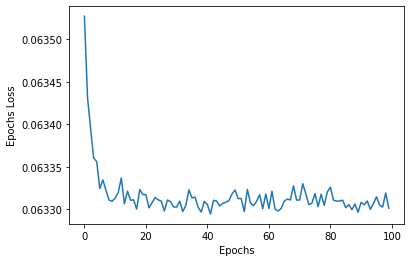

In [14]:
def main():
    
    model, epochs_loss = run()
    
    # plot loss in each epoch
    plt.plot(range(len(epochs_loss)), epochs_loss)
    plt.xlabel('Epochs')
    plt.ylabel('Epochs Loss')
    
    return model
    
model = main()

# Visualize Denoising Test Set

RuntimeError: ignored

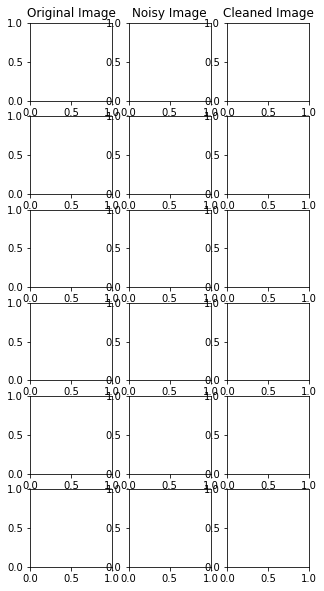

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

f, axes= plt.subplots(6, 3, figsize = (5, 10))
axes[0,0].set_title("Original Image")
axes[0,1].set_title("Noisy Image")
axes[0,2].set_title("Cleaned Image")

for idx, (noisy, clean, label) in enumerate(test_dataloader):
    if idx > 5:
        break
    
    # denoising with DAE
    noisy = noisy.view(noisy.size(0),-1).type(torch.FloatTensor)
    
    # this line must be commented to avoid illegal memory access error
    # noisy = noisy.to(device)
    output = model(noisy)
    
    # fix size
    output = output.view(1, 28, 28)
    output = output.permute(1, 2, 0).squeeze(2)
    output = output.detach().cpu().numpy()
    
    noisy = noisy.view(1, 28, 28)
    noisy = noisy.permute(1, 2, 0).squeeze(2)
    
    # this line must be commented to avoid illegal memory access error
    # noisy = noisy.detach().cpu().numpy()

    clean = clean.view(1, 28, 28)
    clean = clean.permute(1, 2, 0).squeeze(2)
    clean = clean.detach().cpu().numpy()
    
    # plot
    axes[idx, 0].imshow(clean, cmap="gray")
    axes[idx, 1].imshow(noisy, cmap="gray")
    axes[idx, 2].imshow(output, cmap="gray")
    
    axes[idx, 0].set(xticks=[], yticks=[])
    axes[idx, 1].set(xticks=[], yticks=[])
    axes[idx, 2].set(xticks=[], yticks=[])

# Evaluation with Peak Signal to Noise Ratio (PSNR) Metric

In [16]:
def evaluate(model, test_dataloader):
    psnr_noisy = []
    psnr_clean = []
    for noisy, original, label in tqdm(test_dataloader):
        # denoising with DAE
        noisy = noisy.view(noisy.size(0),-1).type(torch.FloatTensor)
        
        # this line must be commented to avoid illegal memory access error
        # noisy = noisy.to(device)
        clean = model(noisy)

        # fix size
        clean = clean.view(1, 28, 28)
        clean = clean.permute(1, 2, 0).squeeze(2)
        clean = clean.detach().cpu().numpy()

        noisy = noisy.view(1, 28, 28)
        noisy = noisy.permute(1, 2, 0).squeeze(2)
        noisy = noisy.detach().cpu().numpy()

        original = original.view(1, 28, 28)
        original = original.permute(1, 2, 0).squeeze(2)
        original = original.detach().cpu().numpy()
        
        psnr_noisy.append(cv2.PSNR(noisy, original))
        psnr_clean.append(cv2.PSNR(clean, original))
        
    return np.mean(psnr_noisy), np.mean(psnr_clean)

In [17]:
psnr_noisy, psnr_clean = evaluate(model, test_dataloader)

  0%|          | 0/10000 [00:00<?, ?it/s]


RuntimeError: ignored

In [18]:
print(f'PSNR improved from {psnr_noisy} for Noisy Images to {psnr_clean} for denoised images by DAE.')

NameError: ignored

# Tried many methods to fix this cuda error issue. It still as is. There were some occations where the functions worked, and other times it seems to fail.

# The program was ran on a local machine, and it was fine. The final result was around a **60.2553023636784 dB**